Question 2 : Chaotic World Of Fractals 

(a) Mandelbrot Set

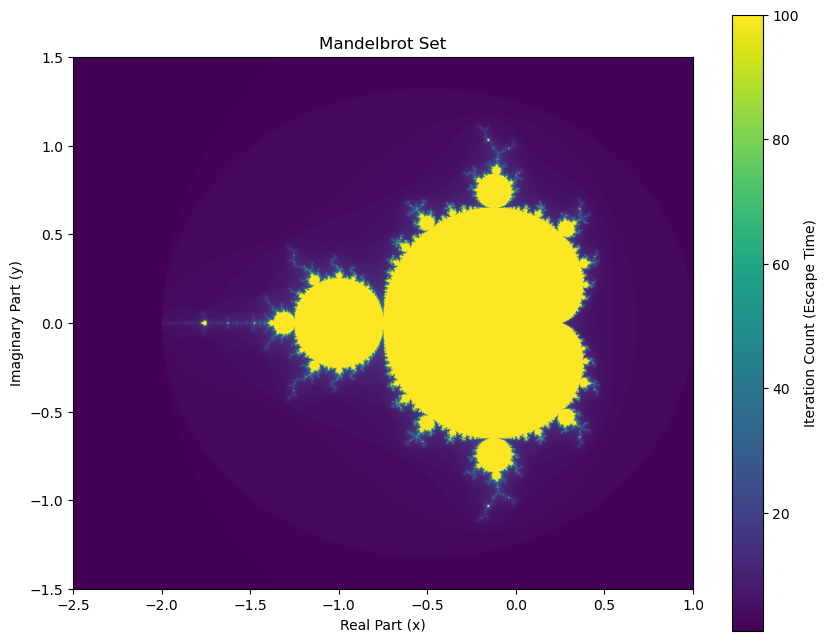

In [ ]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt

# madelbrot function
def mandelbrot(c, maxiter = 100):
    z = 0 + 0j
    for n in range (maxiter):
        if abs(z) > 2:
            return n
        z = z*z + c
    return maxiter

# defining graph parameters
width = 1000
height = 1000
maxiter = 100

x_min, x_max = -2.5, 1
y_min ,y_max = -1.5, 1.5

x_values = np.linspace(x_min, x_max, width)
y_values = np.linspace(y_min, y_max, height)

fractal_image = np.zeros((height, width))

# applying the mandelbrot function to every point of the graph
for i in range (height):
    for j in range(width):
        real_part = x_values[j]
        imaginary_part = y_values[i]
        c = complex(real = real_part, imag= imaginary_part)
        fractal_image[i, j] = mandelbrot(c,maxiter=100) # storing the n in a 2-D array which has same size as that of points in graph

# plotting
plt.figure(figsize = (10, 8))
plt.imshow(fractal_image, extent=[x_min, x_max, y_min, y_max], cmap = 'viridis')
plt.title("Mandelbrot Set")
plt.xlabel("Real Part (x)")
plt.ylabel("Imaginary Part (y)")
plt.colorbar(label='Iteration Count (Escape Time)')
plt.savefig("mandelbrot_set.png", dpi=600)
plt.show()


(b) Newton's Fractal

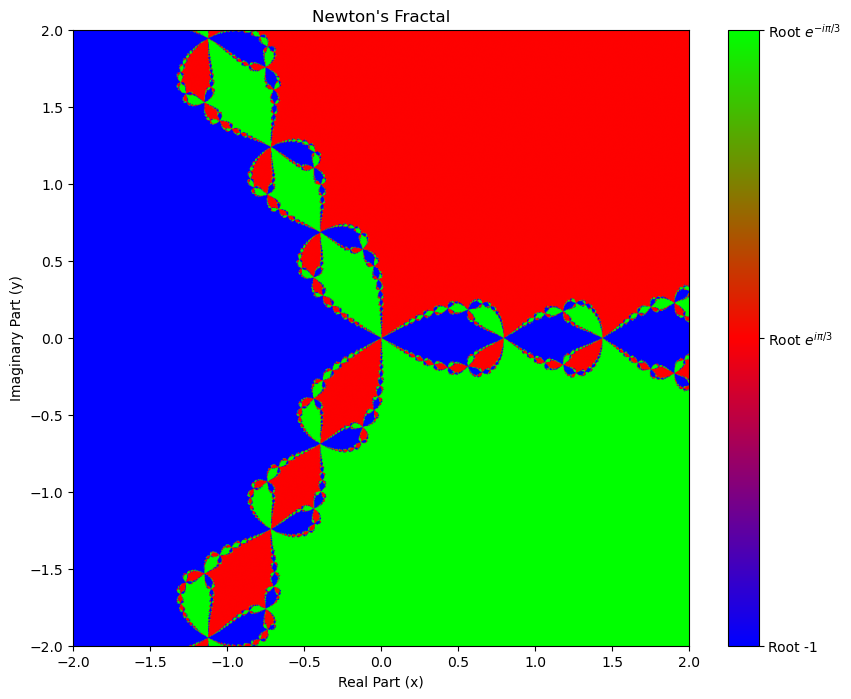

In [2]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt

# newton_fractal function
def newton_fractal(z0, tol = 10**(-6)):
   z = z0
   root_1 = -1
   root_2 = np.exp(1j * np.pi / 3)
   root_3 = np.exp(-1j * np.pi / 3)

   while True: 
      if abs(z) == 0:
         return -1
      z = z - (z**3 + 1) / (3*z**2)

      if abs(z - root_1) < tol: return 0
      if abs(z - root_2) < tol: return 1
      if abs(z - root_3) < tol: return 2

# defining plot parameters
width, height = 1000, 1000
x_min, x_max = -2, 2
y_min, y_max = -2, 2

x_values = np.linspace(x_min, x_max, width)
y_values = np.linspace(y_min, y_max, height)
fractal_image = np.zeros((height, width))

# applying newton_fractal function for every point on the defined graph
for i in range (height):
   for j in range (width):
      z0 = complex(x_values[j], y_values[i])
      fractal_image[i,j] = newton_fractal(z0)

# plotting
plt.figure(figsize=(10, 8))
plt.imshow(fractal_image, extent=[x_min, x_max, y_min, y_max], cmap='brg', origin='lower')
plt.title("Newton's Fractal")
plt.xlabel("Real Part (x)")
plt.ylabel("Imaginary Part (y)")
cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Root -1', 'Root $e^{i\pi/3}$', 'Root $e^{-i\pi/3}$'])
plt.savefig("newton_fractal.png", dpi=600)
plt.show()



(c) Logistic Map and Onset Of Chaos

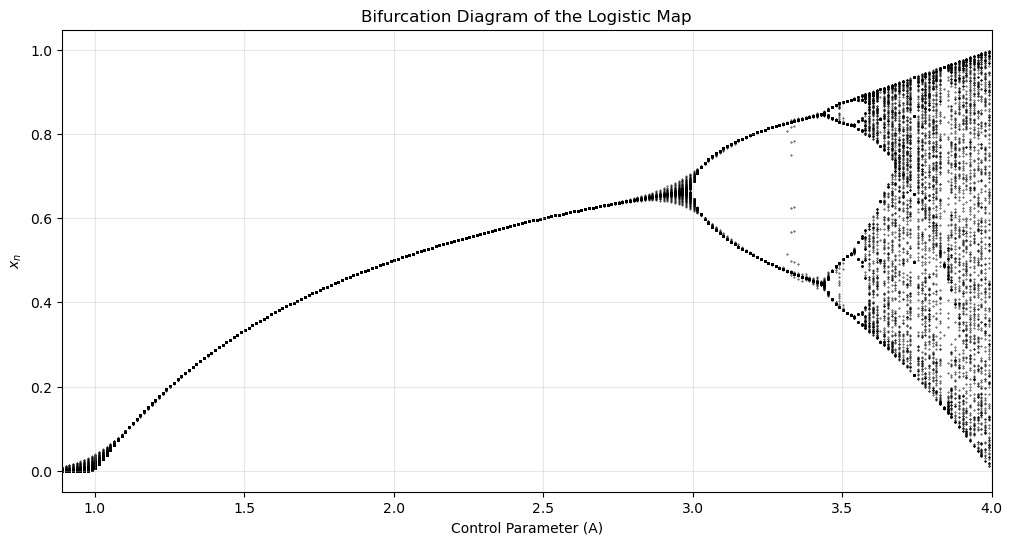

In [4]:
# importing required libraries
import numpy as np
import matplotlib.pyplot as plt
# defining logistic map function
def logistic_map(A, x0, n_iter):
    sequence = [x0]
    for i in range(n_iter):
        x0 = A*x0*(1-x0)
        sequence.append(x0)
    return sequence

A_values = np.arange(0.89, 3.995, 0.0125)
total_steps = 200
transient_steps = 15
x0 = 0.1 # i chose x_initial = 0.1

plot_a = []
plot_x = []
for a in A_values:
    sequence = logistic_map(a, x0, total_steps)
    later_steps = sequence[transient_steps:]
    plot_a.extend([a] * len(later_steps))
    plot_x.extend(later_steps)

#plotting
plt.figure(figsize=(12, 6))
plt.scatter(plot_a, plot_x, s=0.5, color='black', marker='.')
plt.title("Bifurcation Diagram of the Logistic Map")
plt.xlabel("Control Parameter (A)")
plt.ylabel("$x_n$")
plt.xlim(0.89, 4.0)
plt.grid(alpha=0.3)
plt.savefig("bifurcation.png", dpi=600)
plt.show()    


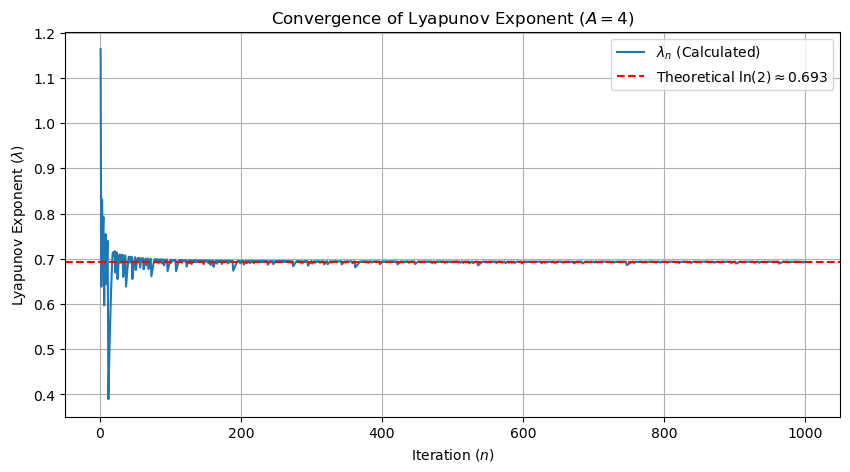

In [5]:
# lyapunov exponent
x0_lyapunov = 0.1
n_iter_lyapunov = 1000
A_lyapunov = 4.0
log_derivative_sum = 0 
lyapunov_exponent = []
x = x0_lyapunov
# calculating lambda_n
for i in range (1, n_iter_lyapunov + 1):
    derivative = A_lyapunov*(1 - 2*x)
    log_derivative_sum += np.log(abs(derivative))
    lambda_n = log_derivative_sum / i
    lyapunov_exponent.append(lambda_n)
    x = A_lyapunov * x * (1 - x)

# plotting
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_iter_lyapunov + 1), lyapunov_exponent, label=r'$\lambda_n$ (Calculated)')
plt.axhline(y=np.log(2), color='red', linestyle='--', label=r'Theoretical $\ln(2) \approx 0.693$')
plt.title(f"Convergence of Lyapunov Exponent ($A=4$)")
plt.xlabel("Iteration ($n$)")
plt.ylabel(r"Lyapunov Exponent ($\lambda$)")
plt.legend()
plt.grid(True)
plt.savefig("lyapunov.png", dpi=600)
plt.show()
